In [ ]:
import fastf1
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

sns.set_theme(style="darkgrid") 

Librerie importate


In [ ]:
#abilito la cache per fastf1 in modo che ogni volta non debba riscaricare i dati. 
fastf1.Cache.enable_cache('../data/cache') #i 2 punti messi all'inizio del path significano "torna su di un livello". 

session = fastf1.get_session(2024, 'Monza', 'R')  # R sta per Race. 
session.load()

print("Seleziono e scarico la sessione da analizzare")

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '4', '55', '44', '1', '63', '11', '23', '20', '14', '43', '3', '31', '10', '77', '27', '24', '18', '22']


Seleziono e scarico la sessione da analizzare


In [ ]:
laps = session.laps #carico i dati dei giri in un dataframe pandas 

print(f"il dataset ha {laps.shape[0]} righe e {laps.shape[1]} colonne")
print("\nColonne disponibili:")
print(laps.columns.tolist())  

il dataset ha 1008 righe e 31 colonne

Colonne disponibili:
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']


In [ ]:
laps.head() 

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:57:18.931000,LEC,16,0 days 00:01:28.179000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:29.989000,...,True,Ferrari,0 days 00:55:50.494000,2024-09-01 13:03:34.413,1,2.0,False,,False,False
1,0 days 00:58:44.327000,LEC,16,0 days 00:01:25.396000,2.0,1.0,NaT,NaT,0 days 00:00:27.707000,0 days 00:00:29.265000,...,True,Ferrari,0 days 00:57:18.931000,2024-09-01 13:05:02.850,1,2.0,False,,False,True
2,0 days 01:00:09.506000,LEC,16,0 days 00:01:25.179000,3.0,1.0,NaT,NaT,0 days 00:00:27.679000,0 days 00:00:29.001000,...,True,Ferrari,0 days 00:58:44.327000,2024-09-01 13:06:28.246,1,2.0,False,,False,True
3,0 days 01:01:34.316000,LEC,16,0 days 00:01:24.810000,4.0,1.0,NaT,NaT,0 days 00:00:27.653000,0 days 00:00:28.883000,...,True,Ferrari,0 days 01:00:09.506000,2024-09-01 13:07:53.425,1,2.0,False,,False,True
4,0 days 01:02:58.919000,LEC,16,0 days 00:01:24.603000,5.0,1.0,NaT,NaT,0 days 00:00:27.630000,0 days 00:00:28.790000,...,True,Ferrari,0 days 01:01:34.316000,2024-09-01 13:09:18.235,1,2.0,False,,False,True


In [ ]:
# giri puliti 

laps_clean = laps[laps['IsAccurate'] == True]
giri_anomali = laps.shape[0] - laps_clean.shape[0]

print(f"Giri totali: {laps.shape[0]}")
print(f"Giri puliti: {laps_clean.shape[0]}")
print(f"Giri anomali: {giri_anomali}")

Giri totali: 1008
Giri puliti: 927
Giri anomali: 81


C:\Users\matte\AppData\Local\Temp\ipykernel_26868\277334063.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lec['LapTimeSeconds'] = lec['LapTime'].dt.total_seconds() # converto il tempo dei giri in secondi


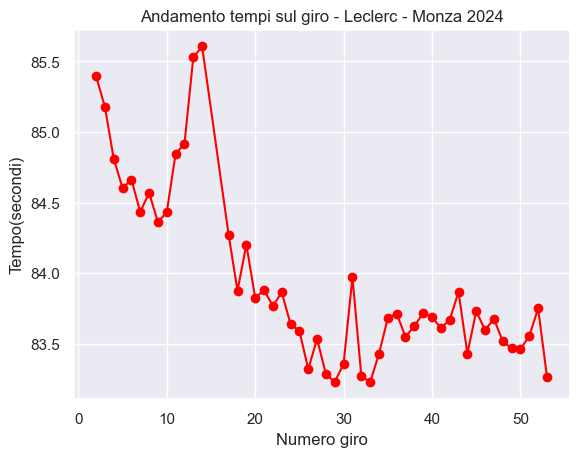

In [ ]:
lec = laps_clean[laps_clean['Driver'] == 'LEC']

lec['LapTimeSeconds'] = lec['LapTime'].dt.total_seconds()  

# grafico 
plt.Figure(figsize=(12, 5))
plt.plot(lec['LapNumber'], lec['LapTimeSeconds'], marker='o', color='red')
plt.title('Andamento tempi sul giro - Leclerc - Monza 2024')
plt.xlabel('Numero giro')
plt.ylabel('Tempo(secondi)')
plt.show() 


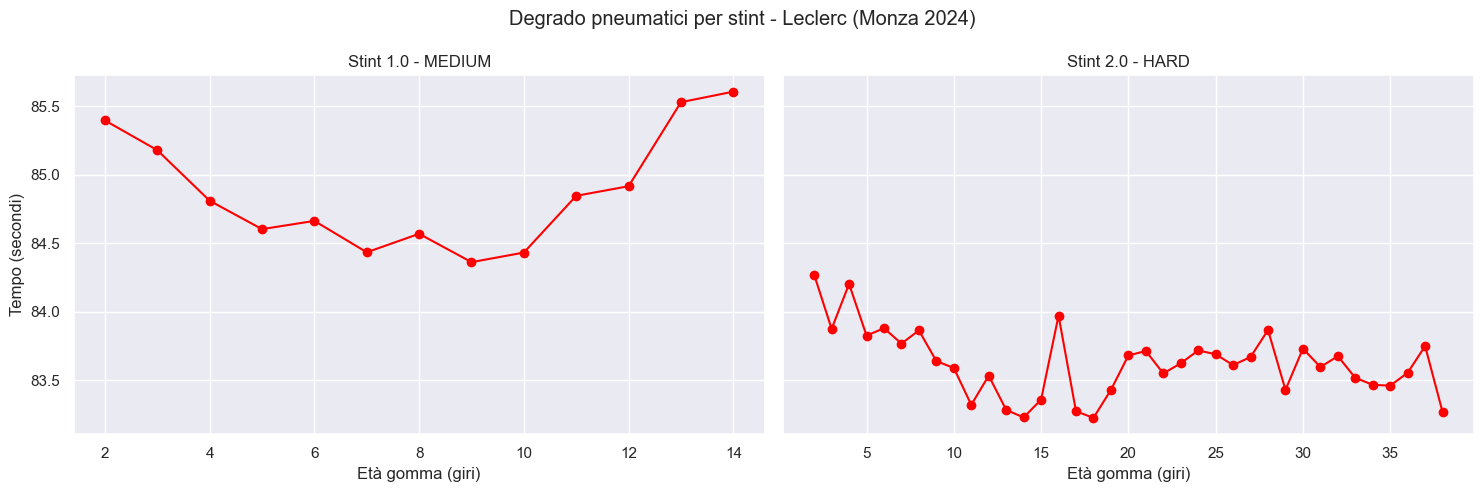

In [ ]:
# Analizziamo ogni stint separatamente
# In ogni stint il carburante cambia poco, quindi il degrado è più visibile

fig, axes = plt.subplots(1, lec['Stint'].nunique(), figsize=(15, 5), sharey=True)       #restituisce una figura intera con all'interno la lista di grafici(axes).
fig.suptitle('Degrado pneumatici per stint - Leclerc (Monza 2024)')                     

for i, stint in enumerate(sorted(lec['Stint'].unique())):
    stint_tabella = lec[lec['Stint'] == stint]
    axes[i].plot(stint_tabella['TyreLife'], stint_tabella['LapTimeSeconds'], 
                 marker='o', color='red')
    axes[i].set_title(f"Stint {stint} - {stint_tabella['Compound'].iloc[0]}") 
    if i == 0:
        axes[i].set_ylabel('Tempo (secondi)')

plt.tight_layout() #fa sì che i grafici non si sovrappongano 
plt.show()

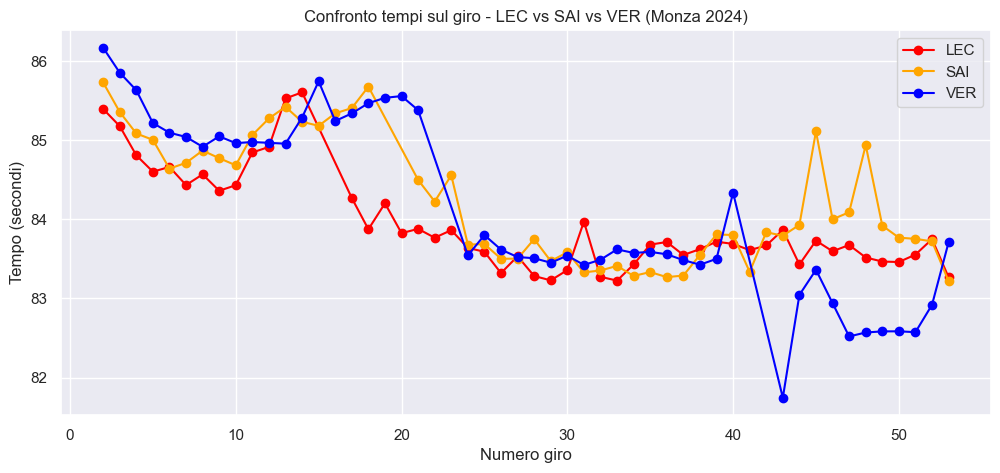

In [ ]:
# seleziono alcuni piloti di interesse per il confronto
# LEC = Leclerc, SAI = Sainz (compagno di squadra), VER = Verstappen
piloti = ['LEC', 'SAI', 'VER']
colori = {'LEC': 'red', 'SAI': 'orange', 'VER': 'blue'}

plt.figure(figsize=(12, 5))

for pilota in piloti:
    dati = laps_clean[laps_clean['Driver'] == pilota]
    dati_copia = dati.copy() 
    dati_copia['LapTimeSeconds'] = dati_copia['LapTime'].dt.total_seconds() 
    plt.plot(dati_copia['LapNumber'], dati_copia['LapTimeSeconds'],
             marker='o', label=pilota, color=colori[pilota])

plt.title('Confronto tempi sul giro - LEC vs SAI vs VER (Monza 2024)')
plt.xlabel('Numero giro')
plt.ylabel('Tempo (secondi)')
plt.legend() 
plt.show()

C:\Users\matte\AppData\Local\Temp\ipykernel_26868\826522506.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=laps_clean, x='Compound', y='LapTimeSeconds', palette='Set2') #grafico di seaborn per confrontare distribuzione statistica dei tempi


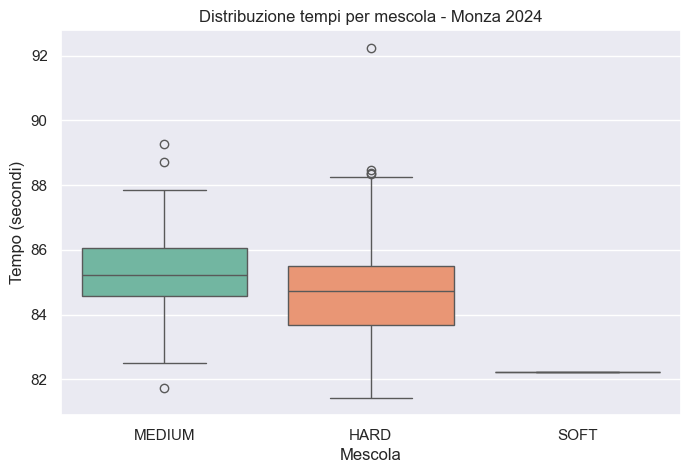

In [ ]:
#Analizzo la DISTRIBUZIONE DEI TEMPI PER MESCOLA

laps_clean = laps_clean.copy() 
laps_clean['LapTimeSeconds'] = laps_clean['LapTime'].dt.total_seconds() 

plt.figure(figsize=(8, 5))
sns.boxplot(data=laps_clean, x='Compound', y='LapTimeSeconds', palette='Set2') 
plt.title('Distribuzione tempi per mescola - Monza 2024')
plt.xlabel('Mescola')
plt.ylabel('Tempo (secondi)')
plt.show()

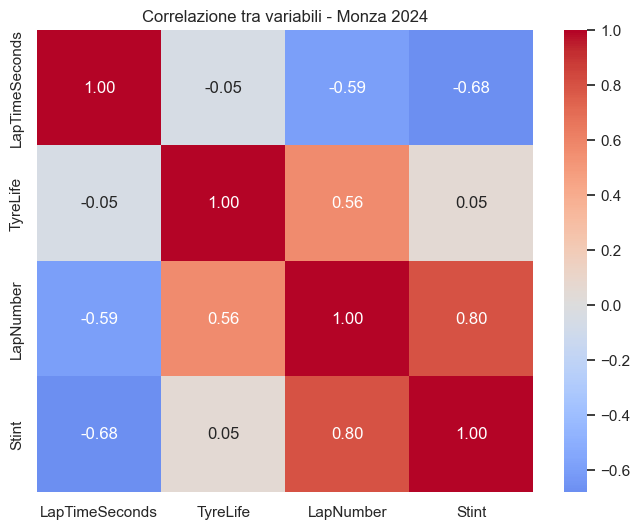

In [ ]:
# CORRELAZIONI TRA VARIABILI

correlazione = laps_clean[['LapTimeSeconds', 'TyreLife', 'LapNumber', 'Stint']].corr() 

plt.figure(figsize=(8, 6))
sns.heatmap(correlazione, annot=True, fmt='.2f', cmap='coolwarm', center=0)  
plt.title('Correlazione tra variabili - Monza 2024')
plt.show()